# 06 — PennyLane Quantum Verification

**Pseudo workflow (from the spec):**

```
load latent_features.npy → angle_encode() → qml.AngleEmbedding()
    → qml.StronglyEntanglingLayers() → measure PauliZ
```

**No GAN yet.** This notebook only verifies that:
1. angles are valid (finite, in `[0, π]`)
2. PennyLane accepts them
3. outputs are differentiable

In [16]:
# ============================================================
# 0. Install / import PennyLane
# ============================================================
%pip install -q pennylane torch

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pennylane as qml
import torch

print("pennylane", qml.__version__)
print("torch    ", torch.__version__)

Note: you may need to restart the kernel to use updated packages.
pennylane 0.45.1
torch     2.6.0+cu124


In [17]:
# ============================================================
# 1. Load angles
# ============================================================
angles = np.load(REPO_ROOT / "data" / "angles.npy")
print("angles:", angles.shape, "range:", (angles.min(), angles.max()))

angles: (147907, 10) range: (np.float64(0.0), np.float64(3.141592653589793))


## 2. Build the 10-qubit circuit

In [18]:
n_qubits = angles.shape[1]          # 10 latent dims -> 10 qubits
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)

np.random.seed(42); torch.manual_seed(42)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit(x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(
        weights=torch.randn(n_layers, n_qubits, 3, requires_grad=True),
        wires=range(n_qubits),
    )
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

print("circuit:")
print(qml.draw(circuit)(angles[0]))
print("\n(weights are trainable -> this is a ready QWGAN generator/encoder block)")


circuit:
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
7: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
8: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
9: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
[0.06139877 1.94430106 0.38931528 1.47546372 1.54134571 1.57789462
 0.95299379 1.20616427 1.71696593 0.85801468]
M1 = 
tensor([[[ 1.9269,  1.4873,  0.9007],
         [-2.1055,  0.6784, -1.2345],
         [-0.0431, -1.6047, -0.7521],
         [ 1.6487, -0.3925, -1.4036],
         [-0.7279, -0.5594, -0.7688],
         [ 0.7624,  1.6423, -0.1596],
         [-0.4974,  0.4396,

In [19]:
# ============================================================
# 3. Forward pass: PennyLane accepts the angles
# ============================================================
sample = torch.tensor(angles[:8], dtype=torch.float64, requires_grad=True)
expectations = circuit(sample)

# PennyLane returns a list of per-qubit expectation tensors;
# stack them into (n_qubits, batch) and transpose to (batch, n_qubits).
expectations = torch.stack(expectations).detach().numpy().T

print("expectation values:", np.asarray(expectations).shape)
print(np.asarray(expectations)[:3])


expectation values: (8, 10)
[[ 2.88968075e-03  2.17575185e-03 -3.45697171e-02  2.71606964e-01
  -1.16841269e-02  2.15310154e-02 -7.26605392e-03 -1.59370466e-02
  -1.22422315e-02 -1.36996082e-03]
 [ 1.11999838e-03 -2.48900196e-04 -6.05867063e-03  2.42933004e-01
  -2.03630347e-03  2.34315410e-02 -2.56020262e-03 -1.46240735e-02
  -6.58766808e-03  1.27090995e-03]
 [ 4.87900936e-03  7.70062947e-03 -3.51995986e-02  2.89853327e-01
  -6.41506764e-03  1.45611036e-02  2.28146061e-03  4.57671537e-02
   1.29644753e-03 -1.13335060e-02]]


In [20]:
# ============================================================
# 4. Differentiability: gradients w.r.t. input angles
# ============================================================
# Use torch autograd (qml.grad on a list-returning torch QNode is
# not supported in PennyLane >= 0.34).
loss = torch.stack(circuit(sample)).sum()
loss.backward()

grad_np = sample.grad.detach().numpy()

print("gradient shape:", grad_np.shape)
print("|grad| sum     :", np.abs(grad_np).sum())
print("grad sample    :", grad_np[0, :5])


gradient shape: (8, 10)
|grad| sum     : 5.702059222496434
grad sample    : [0.016737   0.00155755 0.14306914 0.36411369 0.11649036]


## 5. Full verification report

In [21]:
## 5. Full verification report
import importlib
import src.quantum_encoding as qe
importlib.reload(qe)  # reload in case the module was imported before the fix
from src.quantum_encoding import verify_quantum_circuit

stats = verify_quantum_circuit(angles, n_samples=8, n_layers=2, random_state=42)
print("\nVERIFICATION SUMMARY")
for k, v in stats.items():
    print(f"  {k:24s}: {v}")

assert stats["angles_finite"], "angles contain NaN/Inf"
assert stats["angles_in_range"], "angles out of [0, pi]"
assert stats["differentiable"], "circuit output is not differentiable"
print("\n[ok] All quantum-readiness checks passed.")


[quantum] {'n_qubits': 10, 'n_angles': 147907, 'angles_finite': True, 'angles_in_range': True, 'n_samples_forward': 8, 'expectation_shape': (8, 10), 'expectation_range': [-0.09328576203843986, 0.2455601822102662], 'gradient_abs_sum': 4.870984064507904, 'differentiable': True, 'interface': 'torch', 'diff_method': 'backprop'}

VERIFICATION SUMMARY
  n_qubits                : 10
  n_angles                : 147907
  angles_finite           : True
  angles_in_range         : True
  n_samples_forward       : 8
  expectation_shape       : (8, 10)
  expectation_range       : [-0.09328576203843986, 0.2455601822102662]
  gradient_abs_sum        : 4.870984064507904
  differentiable          : True
  interface               : torch
  diff_method             : backprop

[ok] All quantum-readiness checks passed.


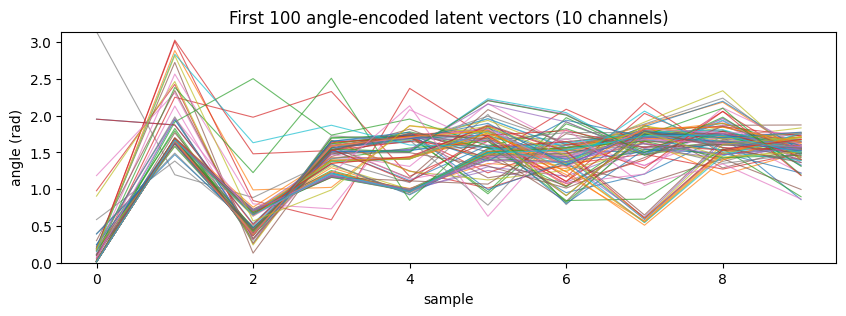

In [22]:
# ============================================================
# 6. (Preview) NISQ-ready: angles are classical data ready to be
#    consumed by a future QWGAN (no GAN yet, per the roadmap).
# ============================================================
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(angles[:100].T, lw=0.8, alpha=0.7)
plt.xlabel("sample"); plt.ylabel("angle (rad)")
plt.title("First 100 angle-encoded latent vectors (10 channels)")
plt.ylim(0, np.pi)
plt.show()